In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
import sys
import gymnasium as gym
import yaml

sys.path.append(os.path.abspath("../envs"))
sys.path.append(os.path.abspath("../models"))
sys.path.append(os.path.abspath("../src"))

# from env1 import TwoAZeroObsOneStep
# from env2 import TwoARandomObsOneStep
# from env3 import LineWorldEasyEnv

from utils_q_learning import *

In [ ]:
with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

### 1)

In [ ]:
experiment_folder = "parte1_1"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["alpha"]
gamma = config[experiment_folder]["gamma"]
epsilon = config[experiment_folder]["epsilon"]
seed = config["xtra"]["seed"]

model_1_path, _ = train_experiment(experiment_folder, env, episodes, alpha, gamma, epsilon, seed)

In [ ]:
experiment_folder = "parte1_1"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
seed = config["xtra"]["seed"]

success_rate = evaluate_Q(model_1_path, env, episodes=100, epsilon=0.0, seed=seed)
print(f"Success rate: {success_rate:.2f}")

Success rate: 1.00


### 2)

In [ ]:
experiment_folder = "parte1_2"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
gamma = config[experiment_folder]["gamma"]
seed = config["xtra"]["seed"]
alphas = [0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
epsilons = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
best_a_eps = search_hyperparameters(experiment_folder, env, episodes, gamma, alphas, epsilons, seed)

Searching hyper:   0%|          | 0/88 [00:00<?, ?it/s]

Best epsilon for alpha 0.5: 0.2 with success rate 0.65
Best epsilon for alpha 0.1: 0.4 with success rate 0.76
Best epsilon for alpha 0.05: 0.3 with success rate 0.76
Best epsilon for alpha 0.01: 0.9 with success rate 0.47
Best epsilon for alpha 0.005: 0.4 with success rate 0.37
Best epsilon for alpha 0.001: 0.4 with success rate 0.25
Best epsilon for alpha 0.0005: 0.4 with success rate 0.25


In [ ]:
experiment_folder = "parte1_2"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
gamma = config[experiment_folder]["gamma"]
seed = config["xtra"]["seed"]
alphas = best_a_eps.keys()
epsilons = best_a_eps.values()
for alpha, eps in zip(alphas, epsilons): #to save the Q
    path, _ = train_experiment(experiment_folder, env, episodes, alpha, gamma, eps, seed)
    success_rate = evaluate_Q(path, env, episodes=100, epsilon=0.0, seed=seed)
    print(f"Success rate for alpha {alpha} and epsilon {eps}: {success_rate:.2f}")

Experiment ../runs/parte1_2/epi_5000_a_0.5_g_0.99_eps_0.2 already exists.
Success rate for alpha 0.5 and epsilon 0.2: 0.00
Experiment ../runs/parte1_2/epi_5000_a_0.1_g_0.99_eps_0.4 already exists.
Success rate for alpha 0.1 and epsilon 0.4: 1.00
Experiment ../runs/parte1_2/epi_5000_a_0.05_g_0.99_eps_0.3 already exists.
Success rate for alpha 0.05 and epsilon 0.3: 1.00
Experiment ../runs/parte1_2/epi_5000_a_0.01_g_0.99_eps_0.9 already exists.
Success rate for alpha 0.01 and epsilon 0.9: 1.00
Experiment ../runs/parte1_2/epi_5000_a_0.005_g_0.99_eps_0.4 already exists.
Success rate for alpha 0.005 and epsilon 0.4: 1.00
Experiment ../runs/parte1_2/epi_5000_a_0.001_g_0.99_eps_0.4 already exists.
Success rate for alpha 0.001 and epsilon 0.4: 1.00
Experiment ../runs/parte1_2/epi_5000_a_0.0005_g_0.99_eps_0.4 already exists.
Success rate for alpha 0.0005 and epsilon 0.4: 1.00
Experiment ../runs/parte1_2/epi_5000_a_0.0001_g_0.99_eps_0.4 already exists.
Success rate for alpha 0.0001 and epsilon 0.

In [ ]:
#write in the config yaml best alpha best epsilon
experiment_folder = "parte1_2"
config[experiment_folder]["best_alpha"] = list(best_a_eps.keys())[1]
config[experiment_folder]["best_epsilon"] = list(best_a_eps.values())[1]
with open("../config/config.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

### 3)

In [ ]:
experiment_folder = "parte1_2"

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["best_alpha"]
gamma = config[experiment_folder]["gamma"]
epsilon = config[experiment_folder]["best_epsilon"]

seed = config["xtra"]["seed"]
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
model3_path, _ = train_experiment(experiment_folder, env, episodes, alpha, gamma, epsilon, seed)

Experiment ../runs/parte1_2/epi_5000_a_0.1_g_0.99_eps_0.4 already exists.


In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
seed = config["xtra"]["seed"]
epsilons = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
succ_rates = []
for epsilon in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    success_rate = evaluate_Q(model3_path, env, episodes=100, epsilon=epsilon, seed=seed)
    succ_rates.append(success_rate)
    print(f"Success rate for epsilon {epsilon}: {success_rate:.2f}")


Success rate for epsilon 0.0: 1.00
Success rate for epsilon 0.1: 0.91
Success rate for epsilon 0.2: 0.81
Success rate for epsilon 0.3: 0.66
Success rate for epsilon 0.4: 0.61
Success rate for epsilon 0.5: 0.38
Success rate for epsilon 0.6: 0.36
Success rate for epsilon 0.7: 0.18
Success rate for epsilon 0.8: 0.06
Success rate for epsilon 0.9: 0.08
Success rate for epsilon 1.0: 0.03


In [ ]:
experiment_2 = "parte1_2"
experiment_folder = "parte1_4"
config[experiment_folder]["gamma"] = config[experiment_2]["gamma"]
config[experiment_folder]["alpha"] = config[experiment_2]["best_alpha"]
with open("../config/config.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

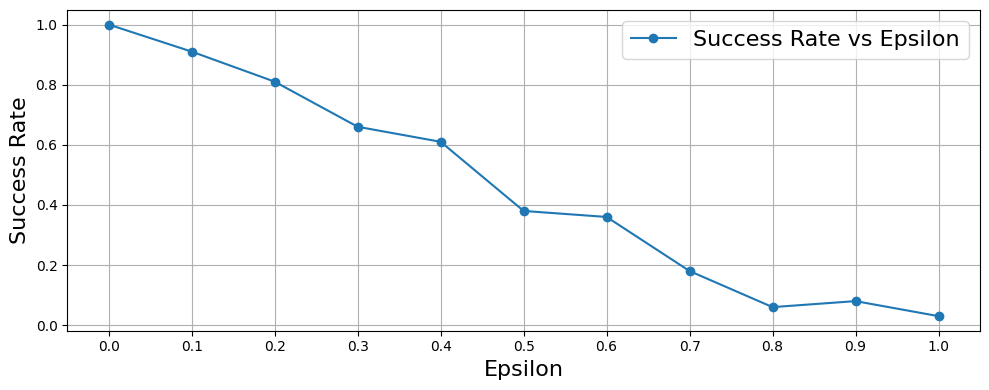

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 4))
plt.plot(epsilons, succ_rates, marker='o', label="Success Rate vs Epsilon")
plt.xlabel("Epsilon", fontsize=16)
plt.ylabel("Success Rate", fontsize=16)
plt.xticks(epsilons)
plt.grid()
plt.tight_layout()
plt.legend(fontsize = 16)
plt.show()

### 4)

In [ ]:
experiment_folder = "parte1_4"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
gamma = config[experiment_folder]["gamma"]
alpha = config[experiment_folder]["alpha"]
seed = config["xtra"]["seed"]
# min_epsilons = [0.1, 0.2, 0.4, 0.6, 0.8, 0.9]
# max_epsilons = [0.2, 0.4, 0.6, 0.8, 0.9, 1.0]
# decays_rate = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0]
min_epsilons = [0.1, 0.2]
max_epsilons = [0.2, 0.4]
decays_rate = [0.01, 0.05]
best_max_decay, global_best = search_eps_decay(experiment_folder, env, episodes, gamma, alpha, min_epsilons, max_epsilons, decays_rate, seed)

Total hyperparameter combinations to evaluate: 6


Searching hyper:   0%|          | 0/6 [00:00<?, ?it/s]

Best max epsilon and decay for min epsilon 0.1: None with success rate 0.00
Best max epsilon and decay for min epsilon 0.2: None with success rate 0.00


In [ ]:
print(global_best)

{'min_epsilon': 0.2, 'max_epsilon': 0.4, 'decay_rate': 0.01, 'success_rate': 1.0}


In [ ]:
experiment_4 = "parte1_4"
experiment_folder = "parte1_5"
config[experiment_folder]["gamma"] = config[experiment_4]["gamma"]
config[experiment_folder]["alpha"] = config[experiment_4]["alpha"]
config[experiment_folder]["min_epsilon"] = global_best["min_epsilon"]
config[experiment_folder]["max_epsilon"] = global_best["max_epsilon"]
config[experiment_folder]["decay_rate"] = global_best["decay_rate"]
with open("../config/config.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

### 5)

In [ ]:
experiment_folder = "parte1_5"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["alpha"]
gamma = config[experiment_folder]["gamma"]
min_epsilon = config[experiment_folder]["min_epsilon"]
max_epsilon = config[experiment_folder]["max_epsilon"]
decay_rate = config[experiment_folder]["decay_rate"]
seed = config["xtra"]["seed"]

model_5_path, _ = train_experiment(experiment_folder, env, episodes, alpha, gamma, min_epsilon, max_epsilon, decay_rate, seed)

In [ ]:
experiment_folder = "parte1_5"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
seed = config["xtra"]["seed"]

success_rate = evaluate_Q(model_5_path, env, episodes=100, epsilon=0.0, seed=seed)
print(f"Success rate: {success_rate:.2f}")

Success rate: 1.00


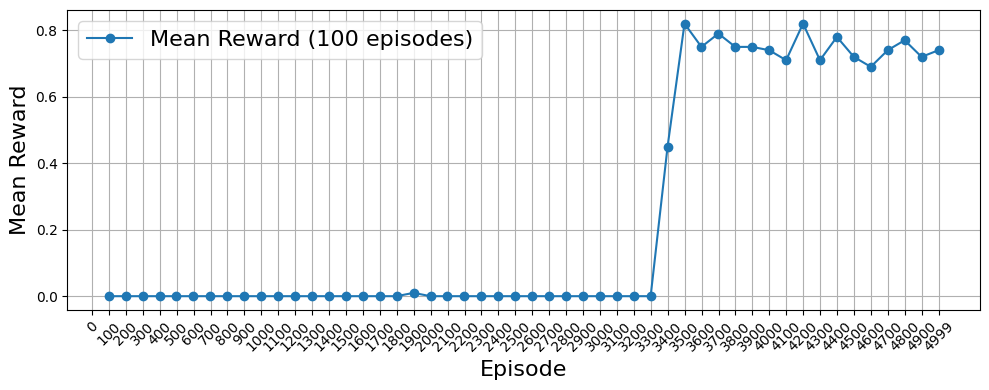

In [ ]:
folder_name = "parte1_5"
window = 100

plot_mean_rewards(folder_name, window)

### 6)

In [ ]:
experiment_folder = "parte1_5"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["alpha"]
gamma = config[experiment_folder]["gamma"]
min_epsilon = config[experiment_folder]["min_epsilon"]
max_epsilon = config[experiment_folder]["max_epsilon"]
decay_rate = config[experiment_folder]["decay_rate"]
seed = config["xtra"]["seed"]

model_5_path, _ = train_experiment(experiment_folder, env, episodes, alpha, gamma, min_epsilon, max_epsilon, decay_rate, seed)

Experiment ../runs/parte1_5/epi_5000_a_0.1_g_0.99_eps_0.2_max_eps_0.4_decay_0.01 already exists.


In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = "rgb_array")
experiment_name = "Frozen_lake_video"
num_episodes = 1
epsilon = 0.0
seed = config["xtra"]["seed"]

record_experiment(model_5_path, experiment_name, env, num_episodes, epsilon, seed)

c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode 1 | Total reward: 1
